# Task 2: Document Comparison (Text vs. Image)
**NewRocket Case Study | Hemanth Chebiyam**

---

## 1. Overview

In this notebook, I compare the similarity between a text-based document and an image-based document (e.g., a documentation screenshot or infographic).

![Flow Diagram](outputs/task2_flow_diagram.png)

### Methodology
1. **OCR Extraction**: Using `pytesseract` to retrieve text from the image.
2. **Lexical Similarity**: TF-IDF Vectorization + Cosine Similarity (keyword-based).
3. **Semantic Similarity**: Sentence-Transformer embeddings + Cosine Similarity (meaning-based).

In [38]:
import os
import pytesseract
from PIL import Image
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import warnings
import pandas as pd
from IPython.display import display, Image as IPImage, Markdown

warnings.filterwarnings('ignore')

# Set Tesseract path for Windows
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# Load semantic model
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

results = []

## 2. Defining Similarity Functions

In [39]:
def get_lexical_similarity(text1, text2):
    vectorizer = TfidfVectorizer()
    tfidf = vectorizer.fit_transform([text1, text2])
    return cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]

def get_semantic_similarity(text1, text2, model):
    emb1 = model.encode(text1)
    emb2 = model.encode(text2)
    return cosine_similarity([emb1], [emb2])[0][0]

def run_comparison_test(case_name, scenario, text_path, image_path):
    # 1. Load Text
    with open(text_path, 'r', encoding='utf-8') as f:
        text_content = f.read()
    
    # 2. Display Inputs
    display(Markdown(f"### Case: {case_name}"))
    display(Markdown(f"**Scenario**: {scenario}"))
    display(Markdown(f"**Source Text Content**:"))
    print(text_content)
    display(Markdown(f"**Document Image**:"))
    display(IPImage(filename=image_path, width=700))
    
    # 3. OCR and Similarity
    image_content = pytesseract.image_to_string(Image.open(image_path))
    lex = get_lexical_similarity(text_content, image_content)
    sem = get_semantic_similarity(text_content, image_content, semantic_model)
    
    # 4. Descriptive Logic
    status = "LOW MATCH"
    explanation = ""
    
    if sem > 0.7:
        status = "HIGH MATCH"
        explanation = "High similarity found: Keywords and underlying meaning align well (Semantic {:.4f}).".format(sem)
    elif sem > 0.35:
        status = "PARTIAL MATCH"
        if lex > sem:
            explanation = "Partial match: Good keyword overlap (Lexical {:.4f}), but overall context (Semantic {:.4f}) differs slightly.".format(lex, sem)
        else:
            explanation = "Partial match: The topics are semantically related (Semantic {:.4f}), even with varying vocabulary (Lexical {:.4f}).".format(sem, lex)
    else:
        status = "LOW MATCH"
        explanation = "Little connection found in keywords (Lexical {:.4f}) or underlying intent (Semantic {:.4f}).".format(lex, sem)

    # 5. Record Results
    res = {
        "Test Case": case_name,
        "Scenario": scenario,
        "Lexical Score": f"{lex:.4f}",
        "Semantic Score": f"{sem:.4f}",
        "Match Status": status,
        "Status Explanation": explanation
    }
    results.append(res)
    
    # 6. Output
    display(Markdown(f"**Status**: {status}"))
    display(Markdown(f"**Explanation**: {explanation}"))
    print(f"\nLexical Similarity: {lex:.4f} | Semantic Similarity: {sem:.4f}")


## 3. Test Cases

### Case 1: High Match (Incident Mapping)

### Case: High Match

**Scenario**: Exact mapping of Incident Report to Screenshot

**Source Text Content**:

Network Outage Incident Report

Incident Number: INC0042891
Date: March 15, 2024
Reported By: IT Operations Center
Priority: 1 - Critical
Category: Network

Summary:
On March 15, 2024, at 09:30 AM, the primary network router in Building A experienced a critical failure. The outage affected approximately 150 users across three departments: Finance, Operations, and HR. All internet and internal network access was lost for the affected users.

Response:
The IT Operations team was notified immediately via the automated monitoring alert at 09:32 AM. A senior network engineer was dispatched within 15 minutes and arrived on-site at 09:47 AM. Remote diagnostics confirmed a hardware failure in the core switch (model: Cisco Catalyst 9300).

Root Cause:
The root cause was identified as a hardware failure in the core switch due to a faulty power supply unit. The unit failed to switch over to the redundant power supply, which had not been tested in the previous maintenance cycle.

Resolution:
A rep

**Document Image**:

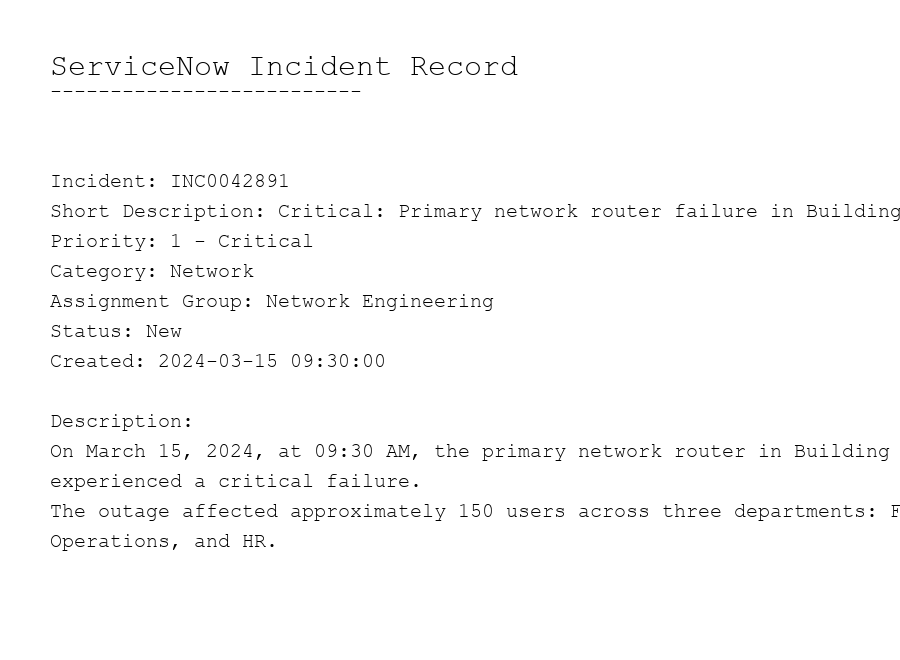

**Status**: HIGH MATCH

**Explanation**: High similarity found: Keywords and underlying meaning align well (Semantic 0.7189).


Lexical Similarity: 0.4393 | Semantic Similarity: 0.7189


In [40]:
run_comparison_test(
    "High Match", 
    "Exact mapping of Incident Report to Screenshot", 
    "task2_comparison/realistic_samples/network_incident_text.txt", 
    "task2_comparison/realistic_samples/incident_screenshot.png"
)

### Case 2: Lexical > Semantic (Opposite Meanings)
Same keywords used in opposing contexts.

### Case: Lexical > Semantic

**Scenario**: Opposite context (Latency Low vs High)

**Source Text Content**:

The server latency is very low today.


**Document Image**:

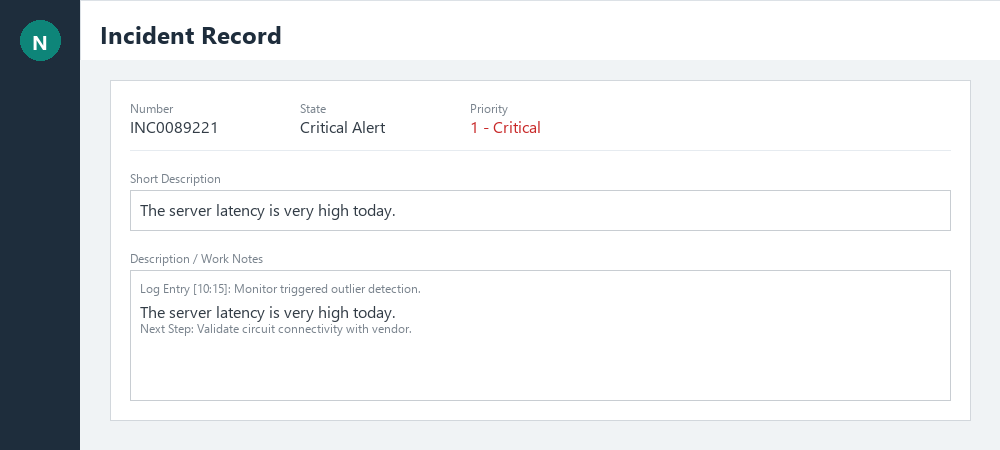

**Status**: PARTIAL MATCH

**Explanation**: Partial match: The topics are semantically related (Semantic 0.4999), even with varying vocabulary (Lexical 0.4960).


Lexical Similarity: 0.4960 | Semantic Similarity: 0.4999


In [41]:
run_comparison_test(
    "Lexical > Semantic", 
    "Opposite context (Latency Low vs High)", 
    "task2_comparison/realistic_samples/lex_vs_sem_text.txt", 
    "task2_comparison/realistic_samples/lex_vs_sem_image.png"
)

### Case 3: Semantic > Lexical (Paraphrased Meaning)
Different words used to convey identical meaning.

### Case: Semantic > Lexical

**Scenario**: Different words, same meaning (Machine vs Computer)

**Source Text Content**:

The machine is unresponsive.


**Document Image**:

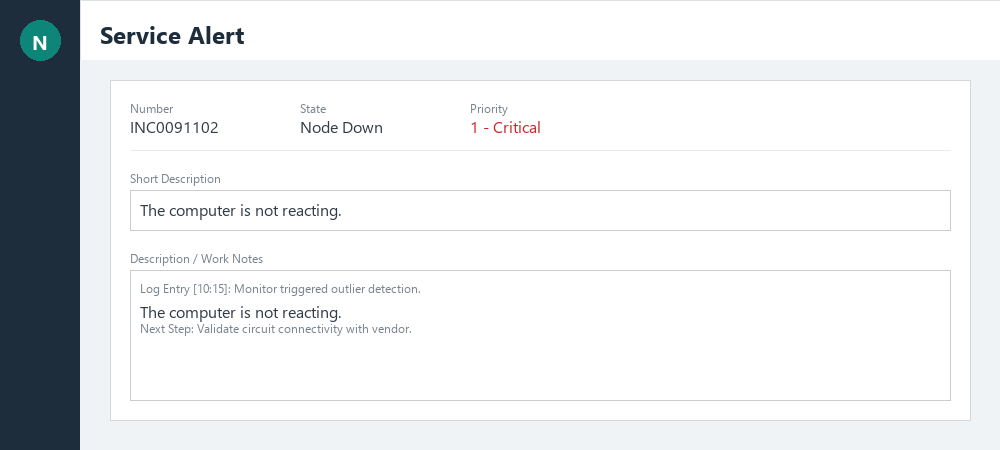

**Status**: PARTIAL MATCH

**Explanation**: Partial match: The topics are semantically related (Semantic 0.3826), even with varying vocabulary (Lexical 0.1506).


Lexical Similarity: 0.1506 | Semantic Similarity: 0.3826


In [42]:
run_comparison_test(
    "Semantic > Lexical", 
    "Different words, same meaning (Machine vs Computer)", 
    "task2_comparison/realistic_samples/sem_vs_lex_text.txt", 
    "task2_comparison/realistic_samples/sem_vs_lex_image.png"
)

### Case 4: Partial Match (KB Article vs Incident)
Subject overlap but structural difference.

### Case: Partial Match

**Scenario**: KB Article vs. Incident Report

**Source Text Content**:

Network Outage Incident Report

Incident Number: INC0042891
Date: March 15, 2024
Reported By: IT Operations Center
Priority: 1 - Critical
Category: Network

Summary:
On March 15, 2024, at 09:30 AM, the primary network router in Building A experienced a critical failure. The outage affected approximately 150 users across three departments: Finance, Operations, and HR. All internet and internal network access was lost for the affected users.

Response:
The IT Operations team was notified immediately via the automated monitoring alert at 09:32 AM. A senior network engineer was dispatched within 15 minutes and arrived on-site at 09:47 AM. Remote diagnostics confirmed a hardware failure in the core switch (model: Cisco Catalyst 9300).

Root Cause:
The root cause was identified as a hardware failure in the core switch due to a faulty power supply unit. The unit failed to switch over to the redundant power supply, which had not been tested in the previous maintenance cycle.

Resolution:
A rep

**Document Image**:

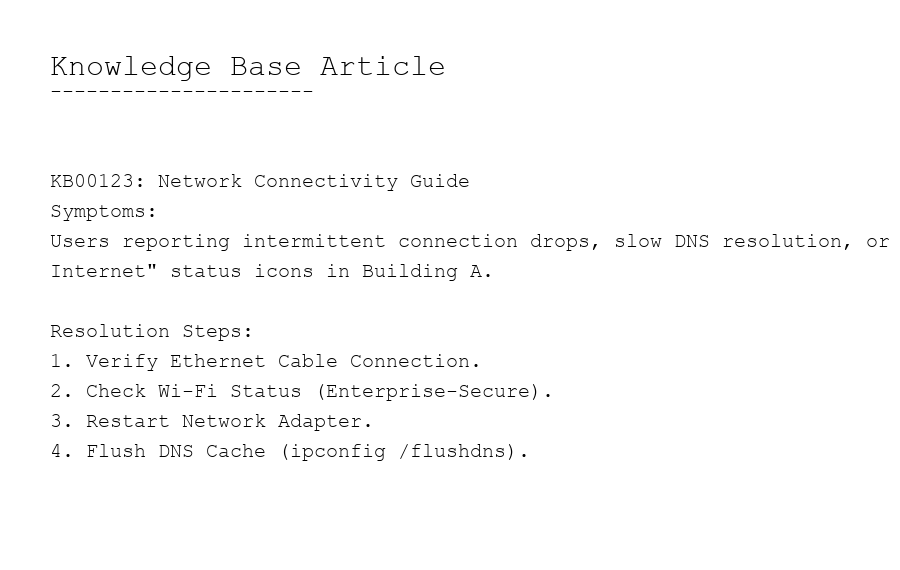

**Status**: PARTIAL MATCH

**Explanation**: Partial match: The topics are semantically related (Semantic 0.3912), even with varying vocabulary (Lexical 0.0849).


Lexical Similarity: 0.0849 | Semantic Similarity: 0.3912


In [43]:
run_comparison_test(
    "Partial Match", 
    "KB Article vs. Incident Report", 
    "task2_comparison/realistic_samples/network_incident_text.txt", 
    "task2_comparison/realistic_samples/kb_article_screenshot.png"
)

### Case 5: Low Match (Unrelated Technical Docs)
Completely different topics.

### Case: Low Match

**Scenario**: Password Reset Flow vs. Network Outage

**Source Text Content**:

Network Outage Incident Report

Incident Number: INC0042891
Date: March 15, 2024
Reported By: IT Operations Center
Priority: 1 - Critical
Category: Network

Summary:
On March 15, 2024, at 09:30 AM, the primary network router in Building A experienced a critical failure. The outage affected approximately 150 users across three departments: Finance, Operations, and HR. All internet and internal network access was lost for the affected users.

Response:
The IT Operations team was notified immediately via the automated monitoring alert at 09:32 AM. A senior network engineer was dispatched within 15 minutes and arrived on-site at 09:47 AM. Remote diagnostics confirmed a hardware failure in the core switch (model: Cisco Catalyst 9300).

Root Cause:
The root cause was identified as a hardware failure in the core switch due to a faulty power supply unit. The unit failed to switch over to the redundant power supply, which had not been tested in the previous maintenance cycle.

Resolution:
A rep

**Document Image**:

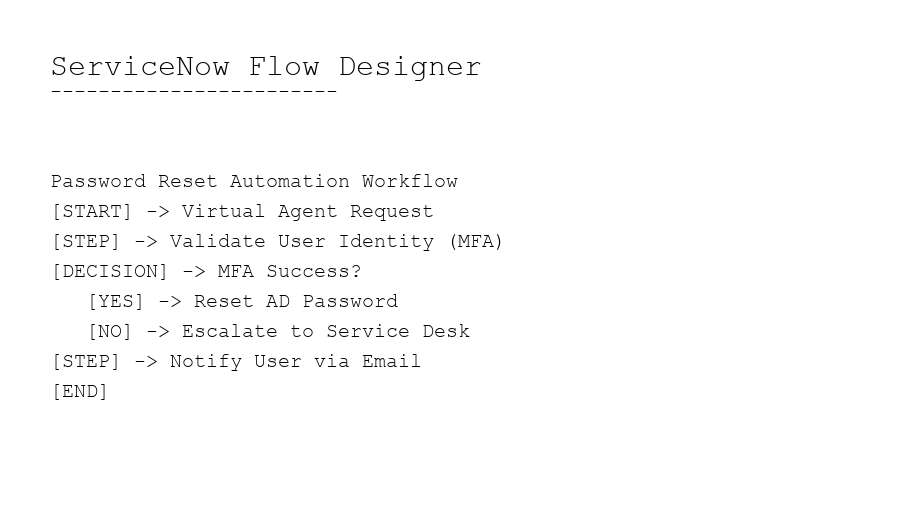

**Status**: LOW MATCH

**Explanation**: Little connection found in keywords (Lexical 0.0144) or underlying intent (Semantic 0.0554).


Lexical Similarity: 0.0144 | Semantic Similarity: 0.0554


In [45]:
run_comparison_test(
    "Low Match", 
    "Password Reset Flow vs. Network Outage", 
    "task2_comparison/realistic_samples/network_incident_text.txt", 
    "task2_comparison/realistic_samples/pwd_reset_flow.png"
)

## 4. Final Comparison Results Table

In [47]:
# Final Results Summary
pd.set_option('display.max_colwidth', None)
df_results = pd.DataFrame(results)
display(Markdown("## Final Results Summary"))
display(df_results)


## Final Results Summary

,Test Case,Scenario,Lexical Score,Semantic Score,Match Status,Status Explanation
0,High Match,Exact mapping of Incident Report to Screenshot,0.4393,0.7189,HIGH MATCH,High similarity found: Keywords and underlying meaning align well (Semantic 0.7189).
1,Lexical > Semantic,Opposite context (Latency Low vs High),0.4960,0.4999,PARTIAL MATCH,"Partial match: The topics are semantically related (Semantic 0.4999), even with varying vocabulary (Lexical 0.4960)."
2,Semantic > Lexical,"Different words, same meaning (Machine vs Computer)",0.1506,0.3826,PARTIAL MATCH,"Partial match: The topics are semantically related (Semantic 0.3826), even with varying vocabulary (Lexical 0.1506)."
3,Partial Match,KB Article vs. Incident Report,0.0849,0.3912,PARTIAL MATCH,"Partial match: The topics are semantically related (Semantic 0.3912), even with varying vocabulary (Lexical 0.0849)."
4,Low Match,Password Reset Flow vs. Network Outage,0.0144,0.0554,LOW MATCH,Little connection found in keywords (Lexical 0.0144) or underlying intent (Semantic 0.0554).
